In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cpp_engine

from gromov_wasserstein import GaussianMixture

In [2]:
def display_gmm(
    gmm, n=400, ax_lim=-12, bx_lim=12, ay_lim=-12, by_lim=12, cmap="Reds", axis=None
):
    if axis is None:
        fig, axis = plt.subplots()
    x = np.linspace(ax_lim, bx_lim, n)
    y = np.linspace(ay_lim, by_lim, n)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y)).reshape(-1, 2)
    Z = gmm.pdf(pos).reshape(n, n)
    axis.set_aspect("equal", adjustable="box")
    z_max = max(Z.max(), 1e-8)
    levels = np.logspace(np.log10(z_max * 1e-3), np.log10(z_max), 7)
    axis.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap=cmap,
        norm=LogNorm(vmin=levels[0], vmax=levels[-1]),
        alpha=1,
    )
    return axis

In [3]:
def entropic_partial_barycentric_interpolation(gmm_1, gmm_2, t, Lambda, reg):
    M = np.zeros((gmm_1.K, gmm_2.K))
    for i in range(gmm_1.K):
        for j in range(gmm_2.K):
            M[i, j] = cpp_engine.GaussianW2(
                gmm_1.comp_mean[i],
                gmm_2.comp_mean[j],
                gmm_1.comp_cov[i],
                gmm_2.comp_cov[j],
            )
    M /= np.max(M)
    W = cpp_engine.entropic_partial_ot(
        gmm_1.weights, gmm_2.weights, M, Lambda, reg, 1000, 1e-7
    )
    new_w, new_m, new_c = [], [], []
    alpha_vec = np.array([1.0 - t, float(t)], dtype=np.float64)
    for i in range(gmm_1.K):
        for j in range(gmm_2.K):
            if W[i, j] > 1e-5:
                m_ij, c_ij = cpp_engine.GaussianBarycenterW2(
                    [gmm_1.comp_mean[i], gmm_2.comp_mean[j]],
                    [gmm_1.comp_cov[i], gmm_2.comp_cov[j]],
                    alpha_vec,
                    20,
                )
                new_w.append(W[i, j])
                new_m.append(m_ij)
                new_c.append(c_ij)
    return GaussianMixture(np.array(new_w) / np.sum(new_w), new_m, new_c)

Calculating row 1/3: $\varepsilon=0.03,\ \Lambda = 0.25$


/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(


Calculating row 2/3: $\varepsilon=0.1,\ \Lambda = 0.25$


/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(


Calculating row 3/3: $\varepsilon=0.03,\ \Lambda = 0.5$


/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_271320/1639543674.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(


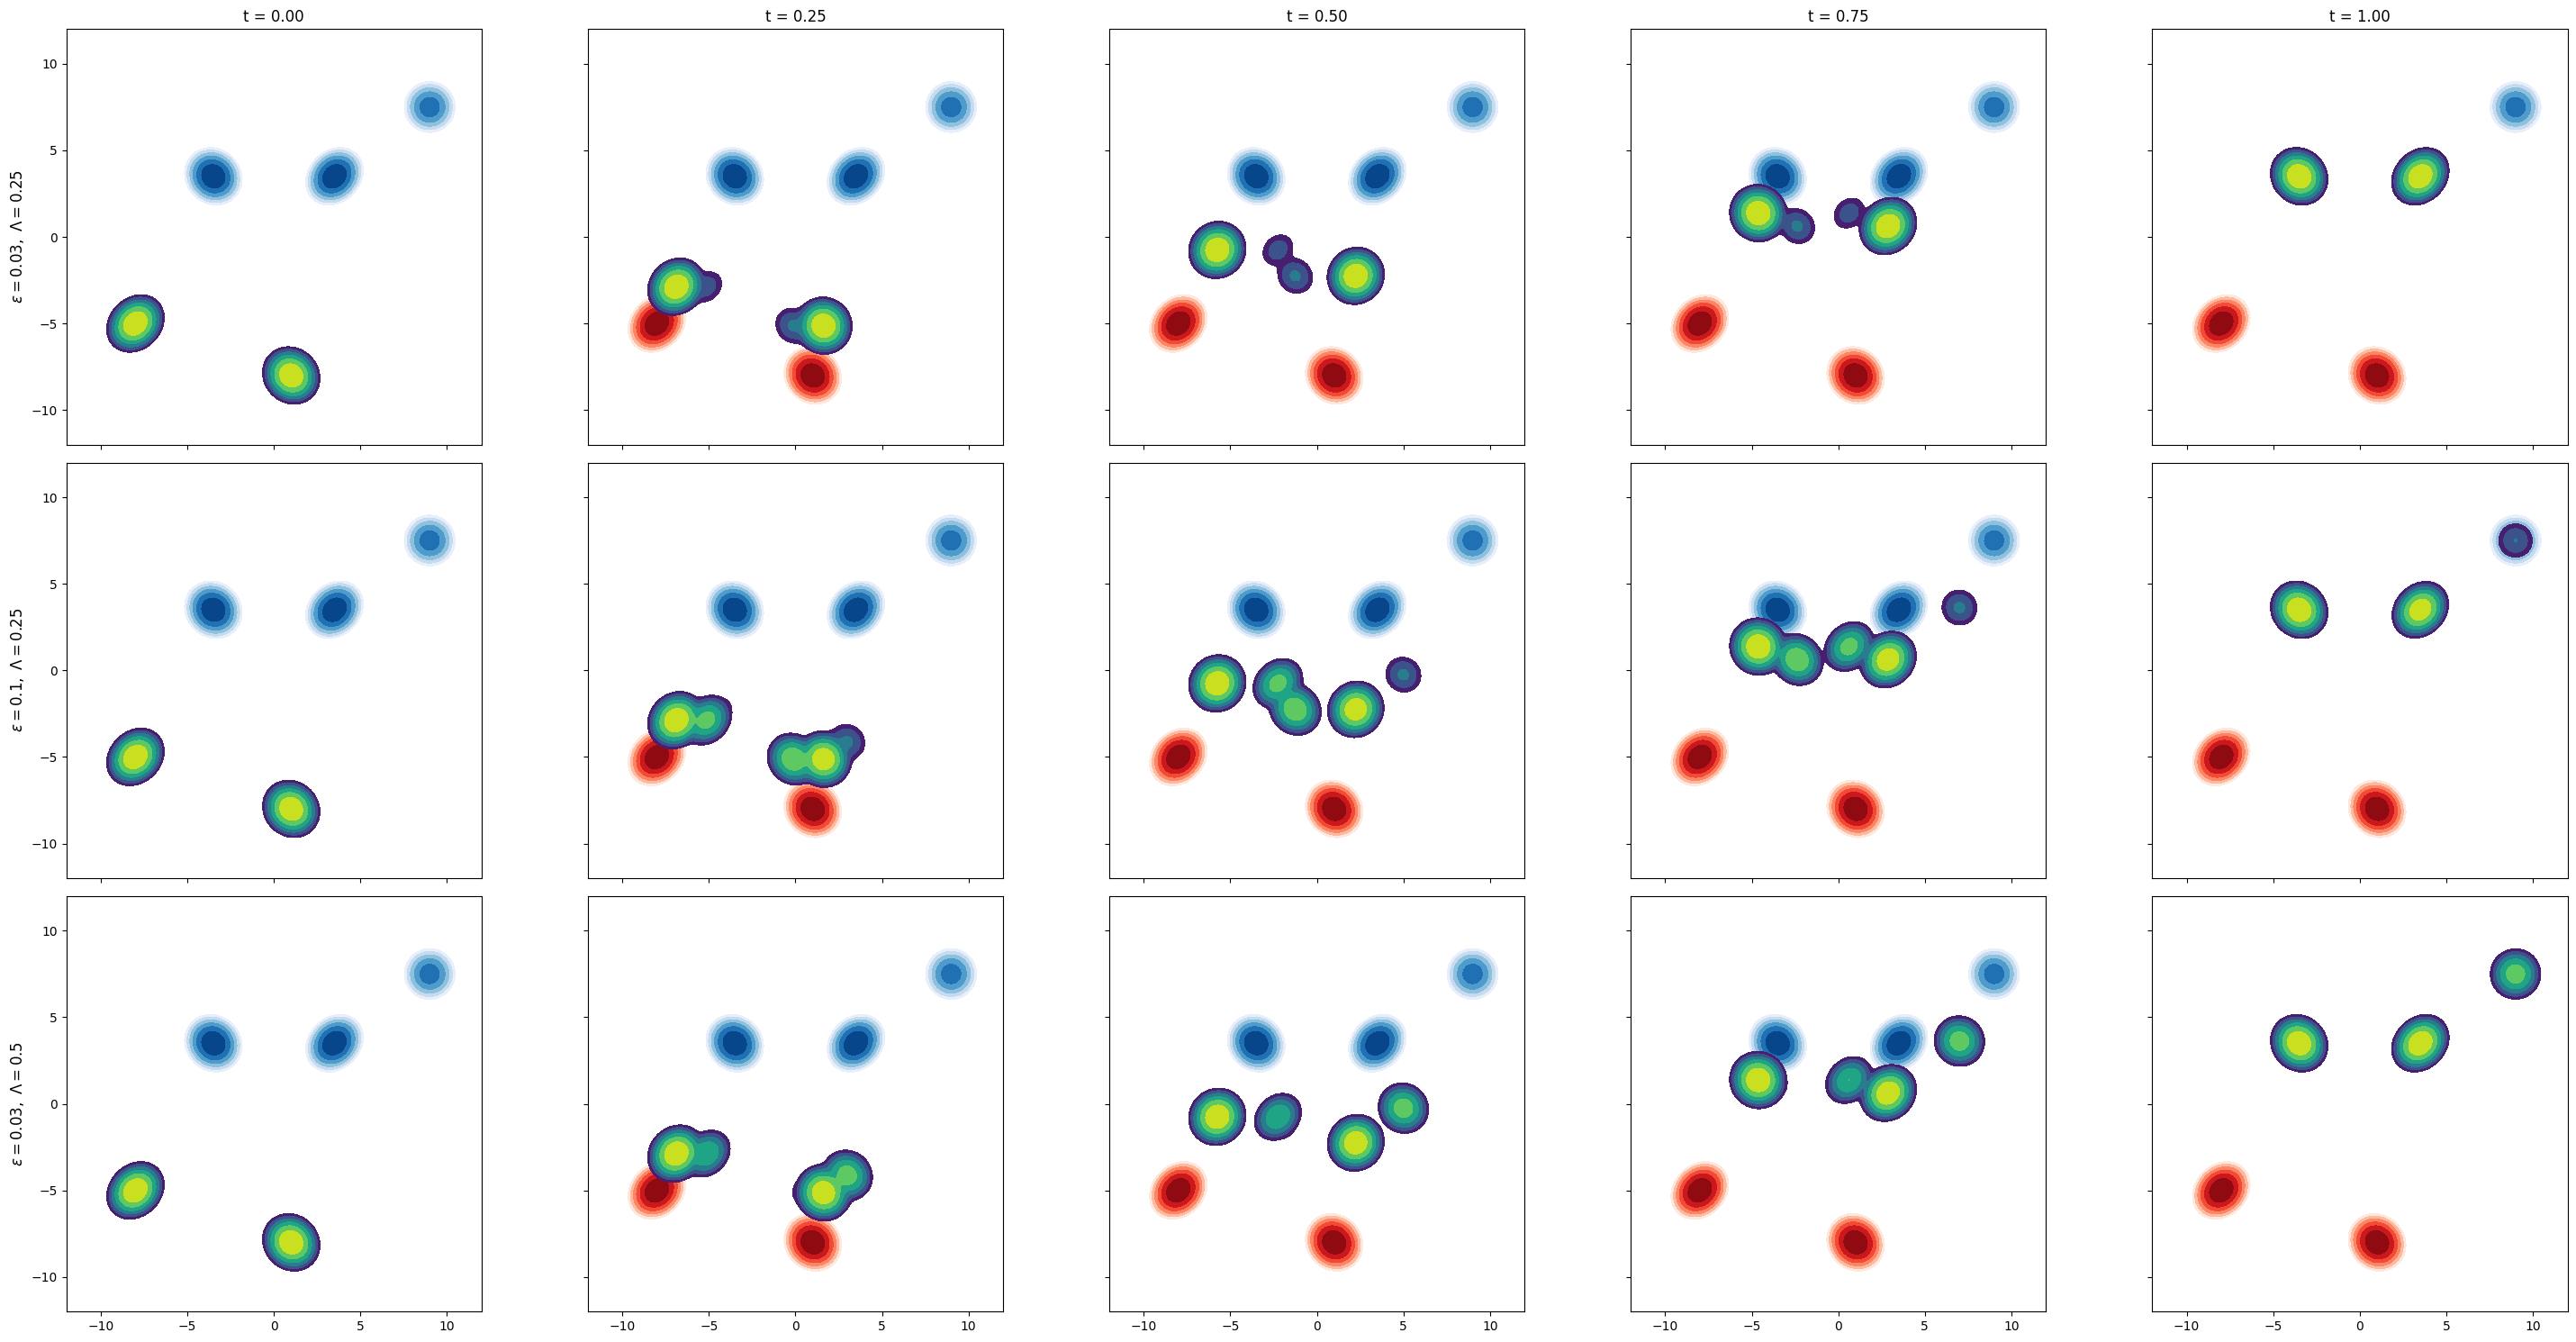

保存完了: comparison_high_res.eps


<Figure size 640x480 with 0 Axes>

In [4]:
# データの定義
alpha_A = np.array([0.5, 0.5])
means_A = np.array([[-8.0, -5.0], [1.0, -8.0]])
covs_A = 0.2 * np.array([[[1, 0.2], [0.2, 1]], [[1, -0.1], [-0.1, 1]]])
Gmm_1 = GaussianMixture(alpha_A, means_A, covs_A)

alpha_B = np.array([0.45, 0.45, 0.1])
means_B = np.array([[-3.5, 3.5], [3.5, 3.5], [9.0, 7.5]])
covs_B = 0.2 * np.array(
    [[[1, -0.1], [-0.1, 1]], [[1, 0.2], [0.2, 1]], [[1, 0.0], [0.0, 1]]]
)
Gmm_2 = GaussianMixture(alpha_B, means_B, covs_B)

t_steps = 5
t_list = np.linspace(0, 1, t_steps)
configs = [
    (r"$\varepsilon=0.03,\ \Lambda = 0.25$", 0.25, 0.03),
    (r"$\varepsilon=0.1,\ \Lambda = 0.25$", 0.25, 0.1),
    (r"$\varepsilon=0.03,\ \Lambda = 0.5$", 0.5, 0.03),
]

fig, axes = plt.subplots(3, t_steps, figsize=(30, 15))

for row_idx, (label, L, R) in enumerate(configs):
    print(f"Calculating row {row_idx + 1}/3: {label}")
    for col_idx, t in enumerate(t_list):
        ax = axes[row_idx, col_idx]
        display_gmm(Gmm_1, cmap="Reds", axis=ax)
        display_gmm(Gmm_2, cmap="Blues", axis=ax)
        gmm_t = entropic_partial_barycentric_interpolation(Gmm_1, Gmm_2, t, L, R)
        display_gmm(gmm_t, cmap="viridis", axis=ax)

        ax.set_xlim(-12, 12)
        ax.set_ylim(-12, 12)
        if row_idx == 0:
            ax.set_title(f"t = {t:.2f}")
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=12, fontweight="bold")
        if col_idx > 0:
            ax.set_yticklabels([])
        if row_idx < 2:
            ax.set_xticklabels([])

plt.tight_layout()
plt.show()  # 修正ポイント: DPIを上げる(300以上)、またはPDFで保存する
output_eps = os.path.join("comparison_high_res.eps")
output_pdf = os.path.join("comparison_high_res.pdf")  # PDFの方が確実

# rasterized=False を明示的に指定（ベクトルを維持）
plt.savefig(output_eps, format="eps", dpi=300, bbox_inches="tight")
plt.savefig(output_pdf, format="pdf", bbox_inches="tight")

print(f"保存完了: {output_eps}")